In [1]:
print("all ok")

all ok


In [1]:
def hello_node(input:str):
    return {"message": f"Hello, {input}!"}

In [2]:
hello_node("sunny")

{'message': 'Hello, sunny!'}

In [3]:
hello_node("rajesh")

{'message': 'Hello, rajesh!'}

In [4]:
hello_node("langgraph")

{'message': 'Hello, langgraph!'}

In [5]:
from typing_extensions import TypedDict

In [7]:
class State(TypedDict):
    message: str

In [14]:
class State:
    message: str

In [15]:
State()

In [13]:
State({"message": "hello python"})

TypeError: 'dict' object is not callable

In [10]:
state: State = {"message": "hello python"}

In [11]:
State

{'message': 'hello python'}

In [16]:
def hello_node(state: State):
    return {"message": f"Hello, {state['message']}!"}

In [17]:
from langgraph.graph import StateGraph, START, END

In [27]:
builder = StateGraph(State)

In [28]:
builder.add_node("first_hello_node",hello_node)

In [29]:
builder.add_edge(START,"first_hello_node")

In [30]:
builder.add_edge("first_hello_node", END)

In [31]:
graph = builder.compile()

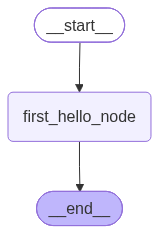

In [32]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [33]:
graph.invoke({"message": "from INDIA"})

{'message': 'Hello, from INDIA!'}

In [34]:
result = graph.invoke({"message": "from INDIA"})

In [35]:
result["message"]

'Hello, from INDIA!'

In [36]:
class Sunny(TypedDict):
    text: str
    

In [ ]:
state: Sunny = {"text": "hello"}

In [39]:
def function1(state: Sunny):
    print(f"state from first function : {state}")
    return {
        "text": state["text"] + " from first function"
    }

In [40]:
def function2(state: Sunny):
    print(f"state from second function : {state}")
    return {
        "text": state["text"] + " savita from second function"
    }

In [42]:
workflow = StateGraph(Sunny)

In [43]:
workflow.add_node("fun1", function1)
workflow.add_node("fun2", function2)

In [44]:
workflow.add_edge(START, "fun1")
workflow.add_edge("fun1", "fun2")
workflow.add_edge("fun2", END)

In [45]:
app = workflow.compile()

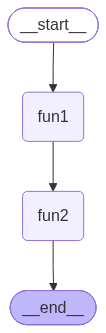

In [46]:
from IPython.display import Image, display

display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)

In [ ]:
#  return {
#         "text": state["text"] + " from first function"
#     }

In [48]:
result = app.invoke({"text": "hi this is sunny"})

state from first function : {'text': 'hi this is sunny'}
state from second function : {'text': 'hi this is sunny from first function'}


In [49]:
result

{'text': 'hi this is sunny from first function savita from second function'}

state from first function before return(this is input to the first function) : {'text': 'hi this is sunny'}
state from second function before return statement(this is output from the first function) : {'text': 'hi this is sunny from first function'}
final state after the section function output: {'text': 'hi this is sunny from first function savita from second function'}

In [50]:
result["text"]

'hi this is sunny from first function savita from second function'